In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


# 1. LOAD DATASET
df = pd.read_csv("../data/dataset.csv", skipinitialspace=True)
print("Dataset gốc:#", df.shape)
print(df.head())


# 2. CHUẨN HÓA NHÃN STAGE
df['Stage'] = df['Stage'].str.upper()

# Tạo nhãn nhị phân: BENIGN hoặc NORMAL → 0 | còn lại → 1
df['Label'] = df['Stage'].apply(lambda x: 0 if x in ['BENIGN', 'NORMAL'] else 1)

# 3. LOẠI BỎ CÁC CỘT OBJECT TRONG FEATURES (TRỪ LABEL)
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Stage là object → xóa, không dùng nữa
if 'Stage' in object_cols:
    object_cols.remove('Stage')

print("\nCác cột object bị loại khỏi X:", object_cols)

# Xóa mọi cột object và xóa thêm Stage
df_clean = df.drop(columns=object_cols + ['Stage'])

print("\nDataset sau khi loại bỏ object columns:", df_clean.shape)

Dataset gốc:# (86691, 85)
                                  Flow ID        Src IP  Src Port  \
0                   8.0.6.4-8.6.0.1-0-0-0       8.6.0.1         0   
1  192.168.3.10-239.2.11.71-53569-8662-17  192.168.3.10     53569   
2        255.255.255.255-0.0.0.0-67-68-17       0.0.0.0        68   
3  192.168.3.30-192.168.3.31-40504-9200-6  192.168.3.30     40504   
4              0.87.248.248-3.0.0.0-0-0-0  0.87.248.248         0   

            Dst IP  Dst Port  Protocol               Timestamp  Flow Duration  \
0          8.0.6.4         0         0  15/07/2019 01:55:21 PM      119998944   
1      239.2.11.71      8662        17  15/07/2019 01:55:22 PM      109235816   
2  255.255.255.255        67        17  15/07/2019 01:55:22 PM      119764062   
3     192.168.3.31      9200         6  15/07/2019 01:55:23 PM      117030424   
4          3.0.0.0         0         0  15/07/2019 01:55:58 PM      119999703   

   Total Fwd Packet  Total Bwd packets  ...    Active Mean     Active St

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86691 entries, 0 to 86690
Data columns (total 86 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Flow ID                     86691 non-null  object 
 1   Src IP                      86691 non-null  object 
 2   Src Port                    86691 non-null  int64  
 3   Dst IP                      86691 non-null  object 
 4   Dst Port                    86691 non-null  int64  
 5   Protocol                    86691 non-null  int64  
 6   Timestamp                   86691 non-null  object 
 7   Flow Duration               86691 non-null  int64  
 8   Total Fwd Packet            86691 non-null  int64  
 9   Total Bwd packets           86691 non-null  int64  
 10  Total Length of Fwd Packet  86691 non-null  float64
 11  Total Length of Bwd Packet  86691 non-null  float64
 12  Fwd Packet Length Max       86691 non-null  float64
 13  Fwd Packet Length Min       866

In [3]:
# 4. CHUẨN BỊ X, y

X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

print("\nClasses Label:", y.value_counts().to_dict())

# 5. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Classes Label: {0: 63712, 1: 22979}

Train size: (69352, 79)
Test size: (17339, 79)


In [4]:
# 5b. ÁP DỤNG SMOTE CHO TRAINING DATA
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTrain size trước SMOTE:", X_train.shape)
print("Train size sau SMOTE:", X_train_res.shape)
print("Classes sau SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


Train size trước SMOTE: (69352, 79)
Train size sau SMOTE: (101938, 79)
Classes sau SMOTE: {1: 50969, 0: 50969}


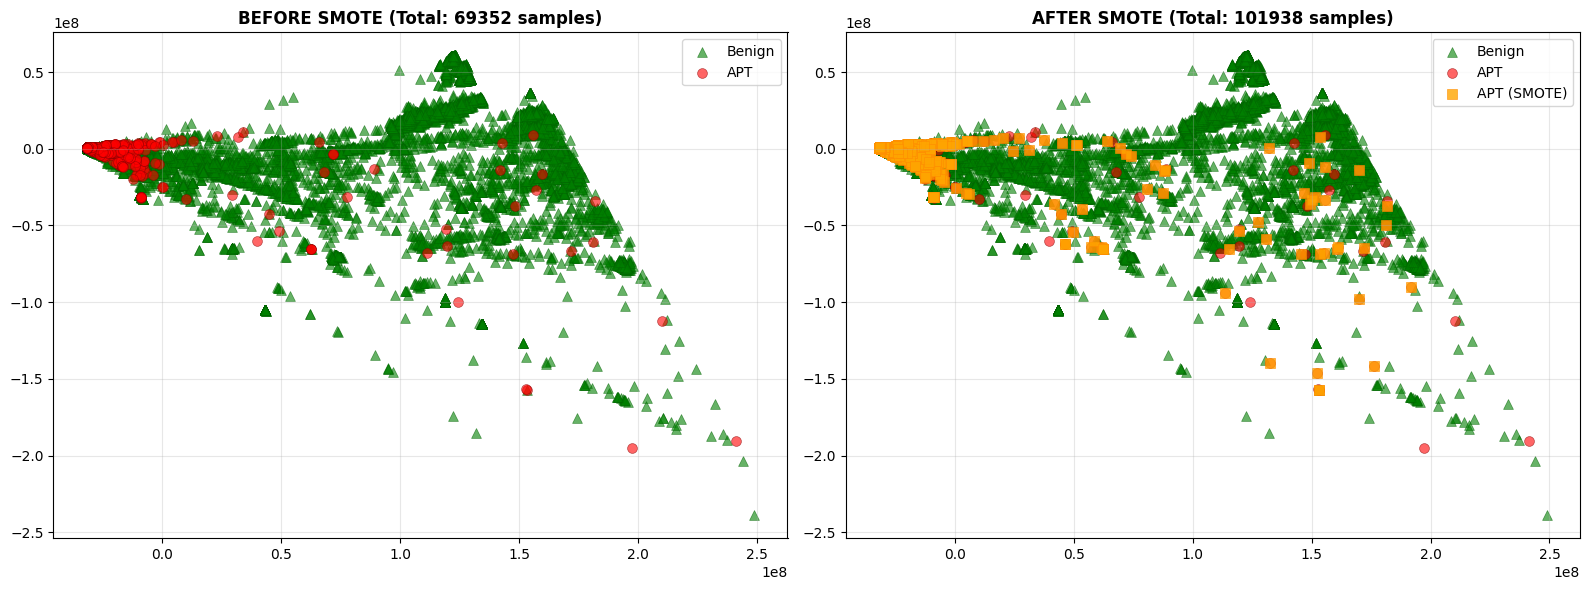


SMOTE DATA ANALYSIS:

BEFORE SMOTE:
  • Total samples: 69352
  • Benign (0): 50969 samples (73.49%)
  • Attack (1): 18383 samples (26.51%)
  • Class imbalance ratio: 2.77:1

AFTER SMOTE:
  • Total samples: 101938
  • Benign (0): 50969 samples (50.00%)
  • Attack (1): 50969 samples (50.00%)
  • Class balance ratio: 1.00:1

SYNTHETIC DATA ADDED:
  • Synthetic samples created: 32586
  • Synthetic Attack samples: 32586
  • Increase percentage: 46.99%



In [6]:
# 5c. VISUALIZE SMOTE DATA - MINH CHỨNG DỮ LIỆU ĐƯỢC THÊM
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# Áp dụng PCA để giảm chiều xuống 2D để có thể visualize
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_train_res_pca = pca.transform(X_train_res)

# Tạo figure với 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Dữ liệu TRƯỚC SMOTE
ax1 = axes[0]
scatter1_benign = ax1.scatter(X_train_pca[y_train == 0, 0], 
                              X_train_pca[y_train == 0, 1],
                              c='green', label='Benign', 
                              alpha=0.6, s=50, edgecolors='darkgreen', linewidth=0.5, marker='^')
scatter1_attack = ax1.scatter(X_train_pca[y_train == 1, 0], 
                              X_train_pca[y_train == 1, 1],
                              c='red', label='APT', 
                              alpha=0.6, s=50, edgecolors='darkred', linewidth=0.5, marker='o')
# ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
# ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax1.set_title(f'BEFORE SMOTE (Total: {len(X_train)} samples)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(alpha=0.3)

# Subplot 2: Dữ liệu SAU SMOTE
ax2 = axes[1]
# Benign class (không thay đổi)
ax2.scatter(X_train_res_pca[y_train_res == 0, 0], 
           X_train_res_pca[y_train_res == 0, 1],
           c='green', label='Benign', 
           alpha=0.6, s=50, edgecolors='darkgreen', linewidth=0.5, marker='^')
# Attack class - original + synthetic
original_indices = y_train == 1
synthetic_indices = np.arange(len(y_train_res)) >= len(y_train)
synthetic_indices = np.concatenate([np.zeros(len(y_train), dtype=bool), 
                                    np.ones(len(y_train_res) - len(y_train), dtype=bool)])

ax2.scatter(X_train_res_pca[y_train_res == 1, 0], 
           X_train_res_pca[y_train_res == 1, 1],
           c='red', label='APT', 
           alpha=0.6, s=50, edgecolors='darkred', linewidth=0.5, marker='o')

# Highlight synthetic samples
synthetic_mask = np.arange(len(y_train_res)) >= len(y_train)
synthetic_attack_mask = synthetic_mask & (y_train_res == 1)
if synthetic_attack_mask.sum() > 0:
    ax2.scatter(X_train_res_pca[synthetic_attack_mask, 0], 
               X_train_res_pca[synthetic_attack_mask, 1],
               c='orange', label='APT (SMOTE)', 
               alpha=0.8, s=50, edgecolors='darkorange', linewidth=0.5, marker='s')

#ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
#ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax2.set_title(f'AFTER SMOTE (Total: {len(X_train_res)} samples)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# In thông tin chi tiết
print(f"\nSMOTE DATA ANALYSIS:")
print(f"{'='*80}")
print(f"\nBEFORE SMOTE:")
print(f"  • Total samples: {len(X_train)}")
print(f"  • Benign (0): {(y_train == 0).sum()} samples ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"  • Attack (1): {(y_train == 1).sum()} samples ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")
print(f"  • Class imbalance ratio: {(y_train == 0).sum() / max((y_train == 1).sum(), 1):.2f}:1")

print(f"\nAFTER SMOTE:")
print(f"  • Total samples: {len(X_train_res)}")
print(f"  • Benign (0): {(y_train_res == 0).sum()} samples ({(y_train_res == 0).sum()/len(y_train_res)*100:.2f}%)")
print(f"  • Attack (1): {(y_train_res == 1).sum()} samples ({(y_train_res == 1).sum()/len(y_train_res)*100:.2f}%)")
print(f"  • Class balance ratio: {(y_train_res == 0).sum() / (y_train_res == 1).sum():.2f}:1")

print(f"\nSYNTHETIC DATA ADDED:")
print(f"  • Synthetic samples created: {len(X_train_res) - len(X_train)}")
print(f"  • Synthetic Attack samples: {(y_train_res == 1).sum() - (y_train == 1).sum()}")
print(f"  • Increase percentage: {((len(X_train_res) - len(X_train)) / len(X_train) * 100):.2f}%")
print(f"\n{'='*80}")

In [8]:
# HIỂN THỊ STAGE VALUES TRƯỚC VÀ SAU SMOTE
print("\n" + "="*80)
print("STAGE VALUES ANALYSIS")
print("="*80)

# Lấy Stage từ df gốc, tương ứng với train set
df_train = df.loc[X_train.index]
stage_train = df_train['Stage']

# Hiển thị unique values và distribution
print(f"\nSTAGE VALUES BEFORE SMOTE:")
print(f"{'─'*80}")
print(f"Unique Stage values: {stage_train.unique()}")
print(f"\nStage Distribution (Train set):")
print(stage_train.value_counts().sort_index())

# Vì SMOTE chỉ tạo synthetic samples cho Attack class (Label=1)
# Nên Stage của Attack samples sẽ được reproduce
print(f"\nSTAGE VALUES AFTER SMOTE:")
print(f"{'─'*80}")

# Tạo stage_train_res bằng cách:
# - Giữ nguyên original samples
# - Thêm stage của Attack samples cho synthetic ones
original_stage = stage_train.values
synthetic_count = len(y_train_res) - len(y_train)

# Lấy Stage của các Attack samples (label=1)
attack_stage = stage_train[y_train == 1].values
# Repeat attack stage values cho synthetic samples
if synthetic_count > 0:
    synthetic_stage = np.repeat(attack_stage, 
                                (synthetic_count + len(attack_stage) - 1) // len(attack_stage))[:synthetic_count]
    stage_train_res = np.concatenate([original_stage, synthetic_stage])
else:
    stage_train_res = original_stage

print(f"Unique Stage values: {np.unique(stage_train_res)}")
print(f"\nStage Distribution (After SMOTE):")
stage_df = pd.DataFrame({
    'Stage': stage_train_res,
    'Label': y_train_res
})
print(stage_df['Stage'].value_counts().sort_index())

print(f"\nSTAGE BREAKDOWN BY CLASS:")
print(f"{'─'*80}")
print("\nBEFORE SMOTE:")
stage_label_before = pd.DataFrame({
    'Stage': stage_train,
    'Label': y_train
}).groupby(['Stage', 'Label']).size().unstack(fill_value=0)
print(stage_label_before)

print("\nAFTER SMOTE:")
stage_label_after = pd.DataFrame({
    'Stage': stage_train_res,
    'Label': y_train_res
}).groupby(['Stage', 'Label']).size().unstack(fill_value=0)
print(stage_label_after)

print(f"\nChi tiết:")
print(f"  • Tổng unique Stage values: {len(np.unique(stage_train_res))}")
print(f"  • Stage values được thêm từ Attack class: {np.unique(attack_stage)}")
print(f"  • Số synthetic Stage samples được tạo: {synthetic_count}")
print(f"\n{'='*80}")



STAGE VALUES ANALYSIS

STAGE VALUES BEFORE SMOTE:
────────────────────────────────────────────────────────────────────────────────
Unique Stage values: ['ESTABLISH FOOTHOLD' 'RECONNAISSANCE' 'BENIGN' 'LATERAL MOVEMENT'
 'DATA EXFILTRATION']

Stage Distribution (Train set):
Stage
BENIGN                50969
DATA EXFILTRATION        14
ESTABLISH FOOTHOLD     6875
LATERAL MOVEMENT       1962
RECONNAISSANCE         9532
Name: count, dtype: int64

STAGE VALUES AFTER SMOTE:
────────────────────────────────────────────────────────────────────────────────
Unique Stage values: ['BENIGN' 'DATA EXFILTRATION' 'ESTABLISH FOOTHOLD' 'LATERAL MOVEMENT'
 'RECONNAISSANCE']

Stage Distribution (After SMOTE):
Stage
BENIGN                50969
DATA EXFILTRATION        36
ESTABLISH FOOTHOLD    19095
LATERAL MOVEMENT       5414
RECONNAISSANCE        26424
Name: count, dtype: int64

STAGE BREAKDOWN BY CLASS:
────────────────────────────────────────────────────────────────────────────────

BEFORE SMOTE:
Label

In [9]:
# 6. CHUẨN HÓA DỮ LIỆU (KNN CẦN STANDARDIZATION)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("\nData scaling hoàn tất")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Data scaling hoàn tất
X_train_scaled shape: (101938, 79)
X_test_scaled shape: (17339, 79)


In [11]:
# 12. TÌMK OPTIMAL - THỬ NHIỀU GIÁ TRỊ K
k_values = range(3, 15, 1)
train_accuracies = []
test_accuracies = []

print("FINDING OPTIMAL K VALUE")

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train_scaled, y_train_res)
    
    # Dự đoán trên train và test
    y_train_pred_temp = knn_temp.predict(X_train_scaled)
    y_test_pred_temp = knn_temp.predict(X_test_scaled)
    
    # Tính accuracy
    train_acc = accuracy_score(y_train_res, y_train_pred_temp)
    test_acc = accuracy_score(y_test, y_test_pred_temp)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"k={k:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(y_test, y_test_pred_temp))

# Tìm k với test accuracy cao nhất
best_k_idx = np.argmax(test_accuracies)
best_k = list(k_values)[best_k_idx]
best_test_acc = test_accuracies[best_k_idx]

FINDING OPTIMAL K VALUE
k= 3 | Train Acc: 0.9914 | Test Acc: 0.9784

=== Confusion Matrix ===
[[12471   272]
 [  102  4494]]
k= 4 | Train Acc: 0.9900 | Test Acc: 0.9797

=== Confusion Matrix ===
[[12522   221]
 [  131  4465]]
k= 5 | Train Acc: 0.9883 | Test Acc: 0.9781

=== Confusion Matrix ===
[[12439   304]
 [   76  4520]]
k= 6 | Train Acc: 0.9876 | Test Acc: 0.9781

=== Confusion Matrix ===
[[12472   271]
 [  109  4487]]
k= 7 | Train Acc: 0.9863 | Test Acc: 0.9776

=== Confusion Matrix ===
[[12429   314]
 [   75  4521]]
k= 8 | Train Acc: 0.9856 | Test Acc: 0.9782

=== Confusion Matrix ===
[[12459   284]
 [   94  4502]]
k= 9 | Train Acc: 0.9842 | Test Acc: 0.9753

=== Confusion Matrix ===
[[12392   351]
 [   77  4519]]
k=10 | Train Acc: 0.9841 | Test Acc: 0.9760

=== Confusion Matrix ===
[[12415   328]
 [   88  4508]]
k=11 | Train Acc: 0.9831 | Test Acc: 0.9742

=== Confusion Matrix ===
[[12364   379]
 [   68  4528]]
k=12 | Train Acc: 0.9829 | Test Acc: 0.9742

=== Confusion Matrix =

In [12]:
# 7. TRAIN KNN
knn = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)

knn.fit(X_train_scaled, y_train_res)
print("\n Model KNN training hoàn tất")

# 8. DỰ ĐOÁN + ĐÁNH GIÁ
y_pred = knn.predict(X_test_scaled)

print("\n=== Accuracy ===")
accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['BENIGN(0)', 'APT(1)']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# 9. LƯU MÔ HÌNH + SCALER
model_path = "../models/knn_model.pkl"
scaler_path = "../models/knn_scaler.pkl"
joblib.dump(knn, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n✅ Mô hình KNN đã được lưu vào: {model_path}")
print(f"✅ Scaler đã được lưu vào: {scaler_path}")


 Model KNN training hoàn tất

=== Accuracy ===
0.9742

=== Classification Report ===
              precision    recall  f1-score   support

   BENIGN(0)       0.99      0.97      0.98     12743
      APT(1)       0.92      0.99      0.95      4596

    accuracy                           0.97     17339
   macro avg       0.96      0.98      0.97     17339
weighted avg       0.98      0.97      0.97     17339


=== Confusion Matrix ===
[[12364   379]
 [   68  4528]]

✅ Mô hình KNN đã được lưu vào: ../models/knn_model.pkl
✅ Scaler đã được lưu vào: ../models/knn_scaler.pkl


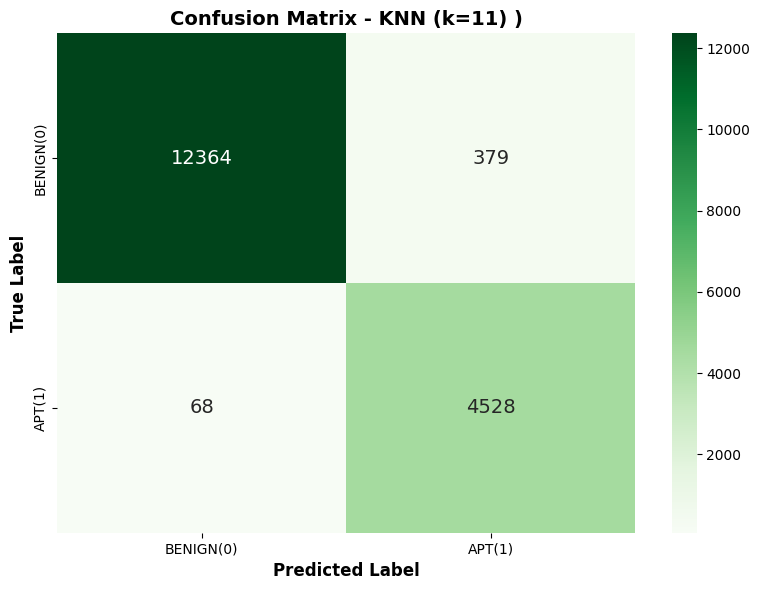

In [14]:
# 10. VISUALIZE CONFUSION MATRIX
fig, ax = plt.subplots(figsize=(8, 6))

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True, 
            xticklabels=['BENIGN(0)', 'APT(1)'],
            yticklabels=['BENIGN(0)', 'APT(1)'],
            ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - KNN (k=11) )', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
print("\n=== KNN Parameters (formatted) ===")
for param, value in knn.get_params().items():
    print(f"{param:25s}: {value}")


=== KNN Parameters (formatted) ===
algorithm                : auto
leaf_size                : 30
metric                   : minkowski
metric_params            : None
n_jobs                   : -1
n_neighbors              : 11
p                        : 2
weights                  : uniform
